In [1]:
# Eksplorativna analiza podataka — UCI HAR Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

pal = ['#4E79A7','#F28E2B','#E15759','#76B7B2','#59A14F','#EDC948']

In [2]:
# 1. Ucitavanje podataka

def uniq(names):
    """Razresava duplikate u imenima feattura dodavanjem sufiksa."""
    seen, result = set(), []
    for x in names:
        candidate = x
        while candidate in seen:
            candidate += 'n'
        result.append(candidate)
        seen.add(candidate)
    return result

with open('UCI HAR Dataset/features.txt') as f:
    uniq_features = uniq([line.split()[1] for line in f])

def load_har(split):
    """Ucitava train/test skup i vraca DataFrame sa featurima i labelama."""
    base = f'UCI HAR Dataset/{split}'
    X = pd.read_csv(f'{base}/X_{split}.txt', sep=r'\s+', header=None, names=uniq_features)
    X['subject'] = pd.read_csv(f'{base}/subject_{split}.txt', header=None).squeeze()
    y = pd.read_csv(f'{base}/y_{split}.txt', header=None).squeeze()
    X['Activity']     = y.values
    X['ActivityName'] = y.map({1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
                                4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}).values
    X.columns = (X.columns.str.replace(r'[()]', '', regex=True)
                           .str.replace(r'[-]',  '', regex=True)
                           .str.replace(r'[,]',  '', regex=True))
    return X

df_train = load_har('train')
df_test  = load_har('test')
print(f"Train: {df_train.shape},  Test: {df_test.shape}")

C:\Users\nikol\AppData\Local\Temp\ipykernel_7916\3945234792.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['subject'] = pd.read_csv(f'{base}/subject_{split}.txt', header=None).squeeze()
C:\Users\nikol\AppData\Local\Temp\ipykernel_7916\3945234792.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['Activity']     = y.values
C:\Users\nikol\AppData\Local\Temp\ipykernel_7916\3945234792.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

Train: (7352, 564),  Test: (2947, 564)


In [3]:
# 2. Provera kvaliteta podataka

print(f"Nedostajuce vrednosti (train): {df_train.isna().sum().sum()}")
print(f"Nedostajuce vrednosti (test) : {df_test.isna().sum().sum()}")
print(f"Duplikati (train): {df_train.duplicated().sum()}")
print(f"Duplikati (test) : {df_test.duplicated().sum()}")

Nedostajuce vrednosti (train): 0
Nedostajuce vrednosti (test) : 0
Duplikati (train): 0
Duplikati (test) : 0


C:\Users\nikol\AppData\Local\Temp\ipykernel_7916\3228739064.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")
C:\Users\nikol\AppData\Local\Temp\ipykernel_7916\3228739064.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")


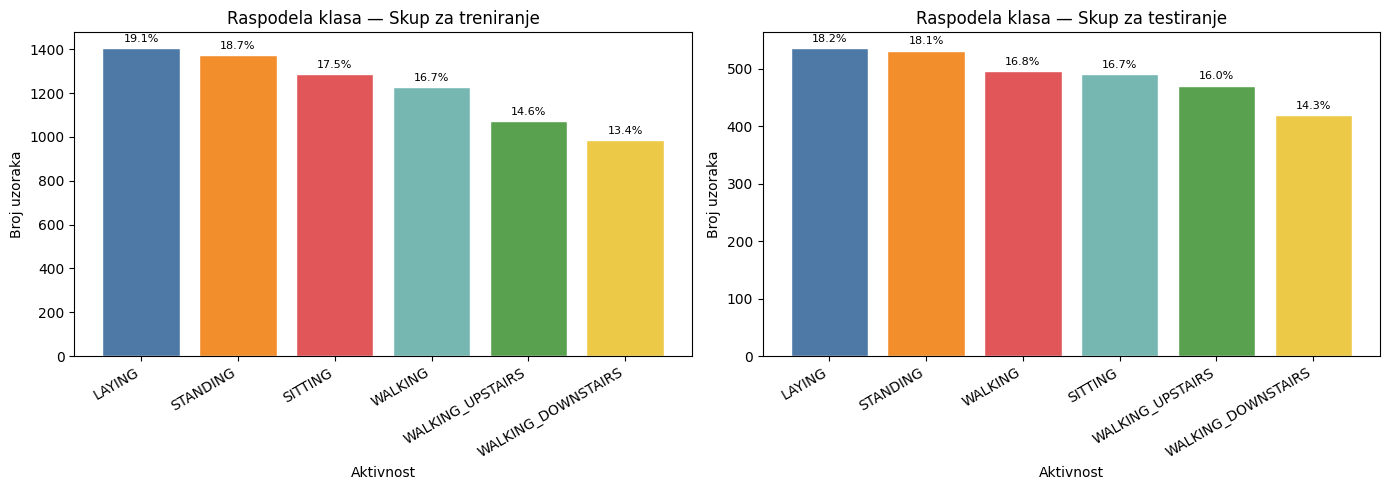

In [4]:
# 3. Raspodela klasa — train i test skup

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, naziv in zip(axes, [df_train, df_test], ["Skup za treniranje", "Skup za testiranje"]):
    counts = df["ActivityName"].value_counts()
    total  = counts.sum()
    pct    = (counts / total * 100).round(1)
    bars   = ax.bar(counts.index, counts.values,
                    color=pal[:len(counts)], edgecolor="white")
    ax.bar_label(bars, labels=[f"{p}%" for p in pct], padding=3, fontsize=8)
    ax.set_title(f"Raspodela klasa — {naziv}")
    ax.set_xlabel("Aktivnost")
    ax.set_ylabel("Broj uzoraka")
    ax.set_xticklabels(counts.index, rotation=30, ha="right")

plt.tight_layout()
plt.savefig("raspodela_klasa.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 4. Raspodela uzoraka po ispitanicima

fig, axes = plt.subplots(1, 2, figsize=(30, 8))

for ax, df, naziv in zip(axes, [df_train, df_test], ["Skup za treniranje", "Skup za testiranje"]):
    sns.countplot(x='subject', hue='ActivityName', palette=pal, data=df, ax=ax)
    ax.set_title(f"Raspodela aktivnosti po ispitaniku — {naziv}")
    ax.set_xlabel("Ispitanik")
    ax.set_ylabel("Broj uzoraka")

plt.tight_layout()
plt.savefig("raspodela_po_ispitanicima.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 5. Srednje vrednosti sa standardnom devijacijom po aktivnosti

reprezentativni_featturi = [
    "tBodyAccmeanX",     # akcelerometar tela
    "tBodyAccstdX",
    "tGravityAccmeanX",  # gravitacija
    "tBodyAccJerkmeanX", # jerk signal
    "tBodyGyromeanX",    # ziroskop
    "tBodyAccMagmean",   # magnituда
    "tBodyAccMagstd",
    "fBodyAccmeanX",     # frekventni domen
    "fBodyGyromeanX",
]

group_means = df_train.groupby("ActivityName")[reprezentativni_featturi].mean()
group_stds  = df_train.groupby("ActivityName")[reprezentativni_featturi].std()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(reprezentativni_featturi):
    axes[i].bar(range(6), group_means[feat], yerr=group_stds[feat],
                capsize=4, color=pal, edgecolor="white")
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].set_xticks(range(6))
    axes[i].set_xticklabels([a.replace("_", "\n") for a in group_means.index],
                             fontsize=6, rotation=15)
    sns.despine(ax=axes[i])

fig.suptitle("Srednje vrednosti po aktivnosti sa standardnom devijacijom",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("barplot_srednje_vrednosti.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 6. Scatter — razdvajanje staticnih aktivnosti

staticne = ["LAYING", "SITTING", "STANDING"]

plt.figure(figsize=(8, 6))
sns.scatterplot(x="tGravityAccmeanZ", y="tGravityAccmeanX",
                hue="ActivityName", palette=pal,
                data=df_train[df_train["ActivityName"].isin(staticne)],
                alpha=0.5, s=20)
plt.title("Razdvajanje staticnih aktivnosti (tGravityAcc Z vs X)")
plt.xlabel("tGravityAcc-mean()-Z")
plt.ylabel("tGravityAcc-mean()-X")
plt.legend(title="Aktivnost", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("scatter_staticne_aktivnosti.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 7. Boxplot energije — staticne vs dinamicne aktivnosti

plt.figure(figsize=(10, 5))
sns.boxplot(x="ActivityName", y="fBodyAccMagenergy", data=df_train, palette=pal,
            order=sorted(df_train["ActivityName"].unique()))
plt.title("Energija frekventnog signala akcelerometra po aktivnosti")
plt.xlabel("Aktivnost")
plt.ylabel("fBodyAccMag-energy")
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("boxplot_energija.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 8. Boxplot entropije — staticne vs dinamicne aktivnosti

plt.figure(figsize=(10, 5))
sns.boxplot(x="ActivityName", y="tBodyAccJerkentropyZ", data=df_train,
            palette=pal, order=sorted(df_train["ActivityName"].unique()))
plt.title("Entropija Jerk signala akcelerometra po aktivnosti")
plt.xlabel("Aktivnost")
plt.ylabel("tBodyAccJerk-entropy()-Z")
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("boxplot_entropija.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 9. Violin — razdvajanje dinamicnih aktivnosti

dinamicne = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS"]
df_din = df_train[df_train["ActivityName"].isin(dinamicne)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, feat in enumerate(["tBodyAccmaxX", "tBodyAccMagstd"]):
    sns.violinplot(x="ActivityName", y=feat, hue="ActivityName",
                   data=df_din, palette=[pal[3], pal[4], pal[5]],
                   ax=axes[i], inner="box", legend=False)
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feat)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15, ha="right")

plt.suptitle("Razdvajanje dinamicnih aktivnosti",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("violin_dinamicne_aktivnosti.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 10. Violin — WALKING vs WALKING_UPSTAIRS

walk_up = df_train[df_train["ActivityName"].isin(["WALKING", "WALKING_UPSTAIRS"])]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, feat in enumerate(["tGravityAccentropyX", "tGravityAccarCoeffY1"]):
    sns.violinplot(x="ActivityName", y=feat, hue="ActivityName",
                   data=walk_up, palette=[pal[3], pal[5]],
                   ax=axes[i], inner="box", legend=False)
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feat)

plt.suptitle("Razdvajanje hodanja i hodanja uz stepenice",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("violin_walking_upstairs.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 11. Violin — SITTING vs STANDING

sit_stand     = df_train[df_train["ActivityName"].isin(["SITTING", "STANDING"])]
best_features = ["tGravityAcccorrelationXY", "tGravityAccmeanY"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, feat in enumerate(best_features):
    sns.violinplot(x="ActivityName", y=feat, hue="ActivityName",
                   data=sit_stand, palette=[pal[3], pal[4]],
                   ax=axes[i], inner="box", legend=False)
    axes[i].set_title(f"SEDENJE vs STAJANJE\n{feat}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feat)

plt.suptitle("Najinformativniji featuri za razdvajanje sedenja i stajanja",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("violin_sedenje_stajanje.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 12. Korelacija feattura sa ciljnom promenljivom

numeric_df = df_train.select_dtypes(include=[np.number]).drop(columns=["subject", "Activity"])
numeric_df["Activity"] = df_train["Activity"]

corr_with_target = numeric_df.corr()["Activity"].drop("Activity")
target_corr = (corr_with_target
               .reindex(corr_with_target.abs().sort_values(ascending=False).index)
               .head(30)
               .to_frame(name="Korelacija sa aktivnoscu"))

plt.figure(figsize=(5, 12))
sns.heatmap(target_corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, cbar_kws={"shrink": 0.6})
plt.title("Top 30 feattura po korelaciji sa ciljnom promenljivom")
plt.tight_layout()
plt.savefig("korelacija_sa_targetom.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 13. Inter-feature korelacija — provera redundantnosti

feat_cols   = [c for c in df_train.columns if c not in ("subject", "Activity", "ActivityName")]
corr_matrix = df_train[feat_cols].corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
visoko_korelirani = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f"Ukupan broj feattura               : {len(feat_cols)}")
print(f"Visoko korelirani featturi (>0.95) : {len(visoko_korelirani)}")
print(f"Preostaje nakon uklanjanja         : {len(feat_cols) - len(visoko_korelirani)}")

In [ ]:
# 14. Korelaciona matrica — reprezentativni featturi

corr_rep = df_train[reprezentativni_featturi].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_rep, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Korelaciona matrica reprezentativnih feattura",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("korelaciona_matrica.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 15. PCA — dvodimenzionalna projekcija

feat_cols = [c for c in df_train.columns if c not in ["Activity", "ActivityName", "subject"]]
X         = df_train[feat_cols].values
y_labels  = df_train["ActivityName"].values

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)

pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100
print(f"PC1: {explained[0]:.1f}%  |  PC2: {explained[1]:.1f}%  |  Ukupno: {explained.sum():.1f}%")

plt.figure(figsize=(9, 7))
for aktivnost, boja in zip(sorted(df_train["ActivityName"].unique()), pal):
    mask = y_labels == aktivnost
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=boja, label=aktivnost, alpha=0.4, s=15, linewidths=0)

plt.xlabel(f"PC1 ({explained[0]:.1f}% varijanse)", fontsize=11)
plt.ylabel(f"PC2 ({explained[1]:.1f}% varijanse)", fontsize=11)
plt.title("PCA projekcija skupa podataka (skup za treniranje)",
          fontsize=13, fontweight="bold")
plt.legend(markerscale=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("pca_projekcija.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# 16. t-SNE — dvodimenzionalna projekcija

X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_scaled)

print("Pokrecem t-SNE, sacekaj oko 1-2 minuta...")
tsne   = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print("Gotovo!")

plt.figure(figsize=(9, 7))
for aktivnost, boja in zip(sorted(df_train["ActivityName"].unique()), pal):
    mask = y_labels == aktivnost
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=boja, label=aktivnost, alpha=0.4, s=15, linewidths=0)

plt.xlabel("t-SNE dimenzija 1", fontsize=11)
plt.ylabel("t-SNE dimenzija 2", fontsize=11)
plt.title("t-SNE projekcija skupa podataka (skup za treniranje)",
          fontsize=13, fontweight="bold")
plt.legend(markerscale=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("tsne_projekcija.png", dpi=120, bbox_inches="tight")
plt.show()